# **ANÁLISIS DE GRANDES VOLÚMENES DE DATOS**

## **TÉCNICAS DE MUESTREO ORIENTADAS AL BIG DATA**

**EQUIPO 51**

* A01797660 - Fernando Arango Gaviria       
* A01796933 - Jose Luis Armenta Mandujano   
* A01797139 - Demenard Gardy Armand         
* A01796617 - Ricardo Ismael Vega Aguilar   



## **Descripción de la Información**

La base de datos utilizada en esta entrega es `charts_artists_daily.csv`, parte del conjunto Spotify Charts Daily Updated.
Recopila el rendimiento diario de las producciones musicales en la plataforma a nivel mundial. La base de datos contiene un histórico de clasificaciones diarias (rankings) segmentado por países.

La base de datos se compone de aproximadamente 22.7 millones de registros.  Cada registro representa la aparición de un artista en el Top 200 de una región específica en una fecha determinada.

Entre los principales atributos disponibles, se cuenta con:

* Fecha (date): Temporalidad diaria del registro.
* País (country/pais): Identificador de la región geográfica.
* Rank (rank): Posición numérica del 1 al 200.
* Artist Name & URI: Identificadores nominal y único del artista.
* Days on Chart: Métrica acumulada de permanencia del artista en la lista.

Los parametros de partición se detallaran mas adelante, pero en resumen son los siguientes:

* **Alcance Local o Global:**  Artistas presentes en mas de 10 paises, se catalogan como Globales.
* **Artista Nuevo o Veterano:**  Artistas con mas de 365 días en el chart, se definen como veteranos.
* **Desempeño (Top o Estable):** Artistas en los primeros 50 lugares en el país, se consideran Top.

## **Inicialización**

In [2]:
import findspark
findspark.init()
findspark.find()

'/opt/miniconda3/envs/env_pyspark/lib/python3.12/site-packages/pyspark'

In [3]:
import os
import sys
import findspark

from pyspark.sql import SparkSession
import pyspark.sql.functions as F

spark = SparkSession.builder \
    .appName("Spotify_BigData_Analysis") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

# Verificación rápida de que el motor encendió
print("Sesión de Spark lista")
spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/10 00:28:59 WARN Utils: Your hostname, Fernandos-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.86.189 instead (on interface en0)
26/05/10 00:28:59 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/10 00:29:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Sesión de Spark lista


In [4]:
!pip install matplotlib
!pip install seaborn

In [5]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11



In [6]:
#Se define la ruta de la base
file_path = '/Users/fernandoarango/Documents/Maestria/Big_Data/Spotify_DataBase/charts_artists_daily.csv'

In [7]:
# Revisando si Spark puede ver el archivo CSV, debe aparecere el tamaño del archivo mayor a 1Gb
print(os.path.exists(file_path))
print(os.path.getsize(file_path) / (1024**3), "GB")

True
2.5764793464913964 GB


## **Carga de la Base y Revisión inicial de los datos**

In [8]:
#Funciones Auxiliares

def entero_seguro(nombre_columna: str):
    return F.when(
        F.col(nombre_columna).cast('string').rlike(r'^-?\d+$'),
        F.col(nombre_columna).cast('int')
    )


def fecha_segura(nombre_columna: str):
    return F.when(
        F.col(nombre_columna).cast('string').rlike(r'^\d{4}-\d{2}-\d{2}$'),
        F.to_date(F.col(nombre_columna))
    )


def banda_rank(columna_rank: str):
    return (
        F.when(F.col(columna_rank) <= 10, '1-10')
        .when(F.col(columna_rank) <= 25, '11-25')
        .when(F.col(columna_rank) <= 50, '26-50')
        .when(F.col(columna_rank) <= 100, '51-100')
        .otherwise('101-200')
    )


ORDEN_BANDAS = ['1-10', '11-25', '26-50', '51-100', '101-200']
ORDEN_LAG = ['0-7', '8-30', '31-180', '181-365', '366-3650']

In [9]:
ruta_artistas = file_path

chart_artistas = (
    spark.read.option('header', True).csv(str(ruta_artistas))
    .select(
        fecha_segura('date').alias('fecha'),
        F.col('country').alias('pais'),
        entero_seguro('rank').alias('rank'),
        F.col('uri').alias('artist_uri'),
        F.col('artist_name').alias('artist_name'),
        entero_seguro('peak_rank').alias('peak_rank'),
        entero_seguro('previous_rank').alias('previous_rank'),
        entero_seguro('days_on_chart').alias('days_on_chart'),
        entero_seguro('consecutive_days').alias('consecutive_days'),
        F.col('entry_status').alias('entry_status'),
        entero_seguro('entry_rank').alias('entry_rank'),
        fecha_segura('entry_date').alias('entry_date')
    )
)

In [10]:
#Validación del tipo de datos
chart_artistas.dtypes

[('fecha', 'date'),
 ('pais', 'string'),
 ('rank', 'int'),
 ('artist_uri', 'string'),
 ('artist_name', 'string'),
 ('peak_rank', 'int'),
 ('previous_rank', 'int'),
 ('days_on_chart', 'int'),
 ('consecutive_days', 'int'),
 ('entry_status', 'string'),
 ('entry_rank', 'int'),
 ('entry_date', 'date')]

In [11]:
resumen_spark = chart_artistas.select(
    F.lit("Artistas diarios").alias("dataset"),
    F.count("*").alias("filas"),
    F.countDistinct("pais").alias("paises"),
    F.countDistinct("artist_name").alias("artistas_distintos"),
    F.countDistinct("artist_uri").alias("artistas_distintos_uri"),
    F.min("fecha").alias("fecha_min"),
    F.max("fecha").alias("fecha_max")
)

resumen_cobertura = resumen_spark.toPandas()

display(resumen_cobertura)

,dataset,filas,paises,artistas_distintos,artistas_distintos_uri,fecha_min,fecha_max
0,Artistas diarios,22711258,71,22819,23155,2021-10-21,2026-05-02


In [12]:
resumen_calidad_spark = chart_artistas.select(
    F.lit("artistas").alias("tabla"),
    F.sum(F.when(F.col("rank").isNull(), 1).otherwise(0)).alias("filas_rank_invalido"),
    F.sum(F.when(F.col("fecha").isNull(), 1).otherwise(0)).alias("filas_fecha_invalida"),
    F.sum(F.when(F.col("days_on_chart").isNull(), 1).otherwise(0)).alias("filas_days_on_chart_invalido"),
    F.sum(F.when(F.col("artist_name").isNull() | (F.col("artist_name") == ""), 1).otherwise(0)).alias("filas_nombre_artista_invalido")
)

resumen_calidad = resumen_calidad_spark.toPandas()

display(resumen_calidad)

,tabla,filas_rank_invalido,filas_fecha_invalida,filas_days_on_chart_invalido,filas_nombre_artista_invalido
0,artistas,0,0,0,0


## **Analisis de información**

### Insight 1: concentracion del liderazgo en el puesto #1

In [13]:
top_no1 = (
    chart_artistas.where(F.col('rank') == 1)
    .groupBy('artist_name')
    .agg(
        F.count('*').alias('dias_pais_en_no1'),
        F.countDistinct('pais').alias('paises_con_no1')
    )
    .orderBy(F.desc('dias_pais_en_no1'))
    .toPandas()
)

top_no1.head(15)

,artist_name,dias_pais_en_no1,paises_con_no1
0,Bad Bunny,25666,40
1,Taylor Swift,16612,51
2,The Weeknd,4662,41
3,Drake,4181,30
4,Arijit Singh,2972,3
5,BTS,2431,31
6,Jay Chou,1556,4
7,ElGrandeToto,1519,1
8,Viktor Sheen,1498,2
9,Jul,1242,4


Los 10 artistas con mas dias-pais en el puesto #1 concentran el 53.3% de todos los liderazgos del dataset.
El artista mas dominante es Bad Bunny con 25,666 dias-pais en #1 y presencia de liderazgo en 40 paises.


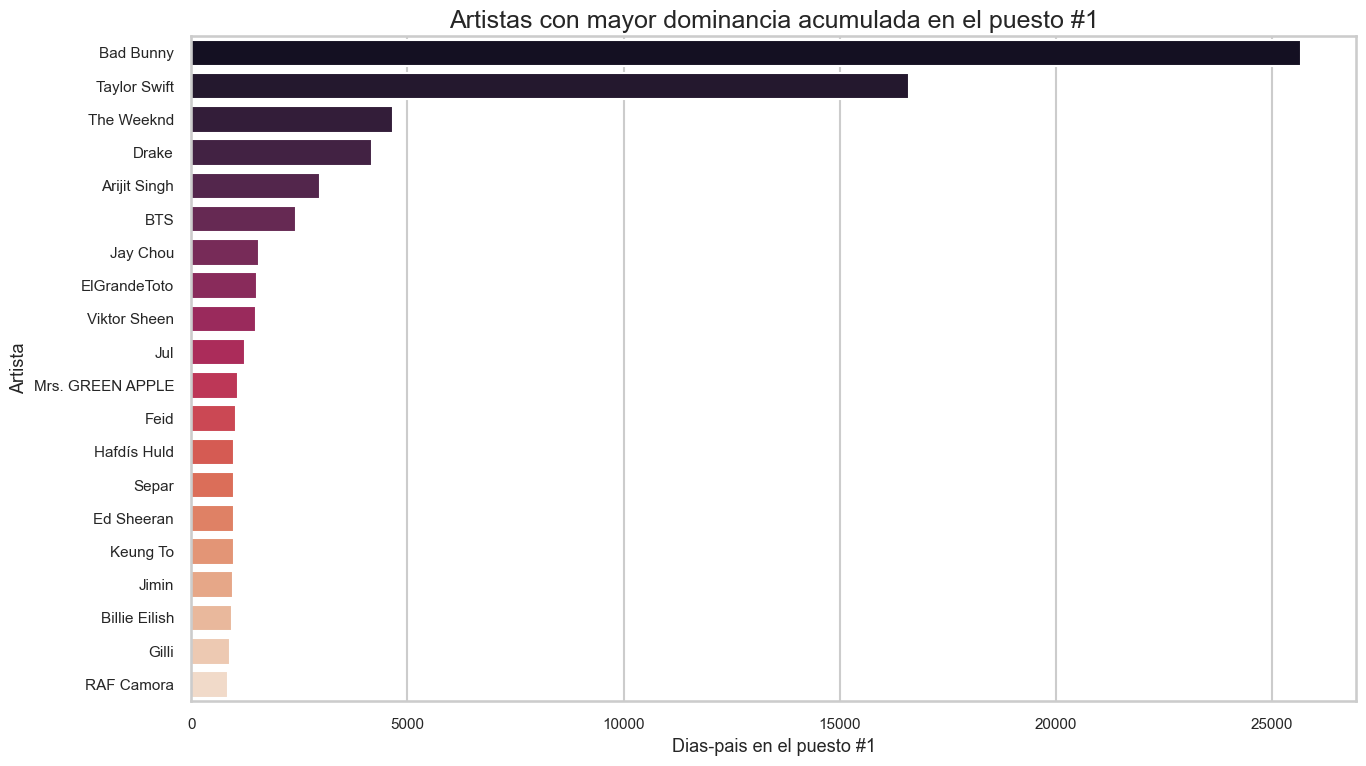

In [14]:
if not top_no1.empty:
    total_no1 = top_no1['dias_pais_en_no1'].sum()
    share_top10 = top_no1.head(10)['dias_pais_en_no1'].sum() / total_no1
    lider = top_no1.iloc[0]
    print(f"Los 10 artistas con mas dias-pais en el puesto #1 concentran el {share_top10:.1%} de todos los liderazgos del dataset.")
    print(f"El artista mas dominante es {lider['artist_name']} con {int(lider['dias_pais_en_no1']):,} dias-pais en #1 y presencia de liderazgo en {int(lider['paises_con_no1'])} paises.")

    plt.figure(figsize=(14, 8))
    sns.barplot(data=top_no1.head(20), x='dias_pais_en_no1', y='artist_name', palette='rocket')
    plt.title('Artistas con mayor dominancia acumulada en el puesto #1')
    plt.xlabel('Dias-pais en el puesto #1')
    plt.ylabel('Artista')
    plt.tight_layout()
    plt.show()


### Insight 2: alcance global vs dominancia local

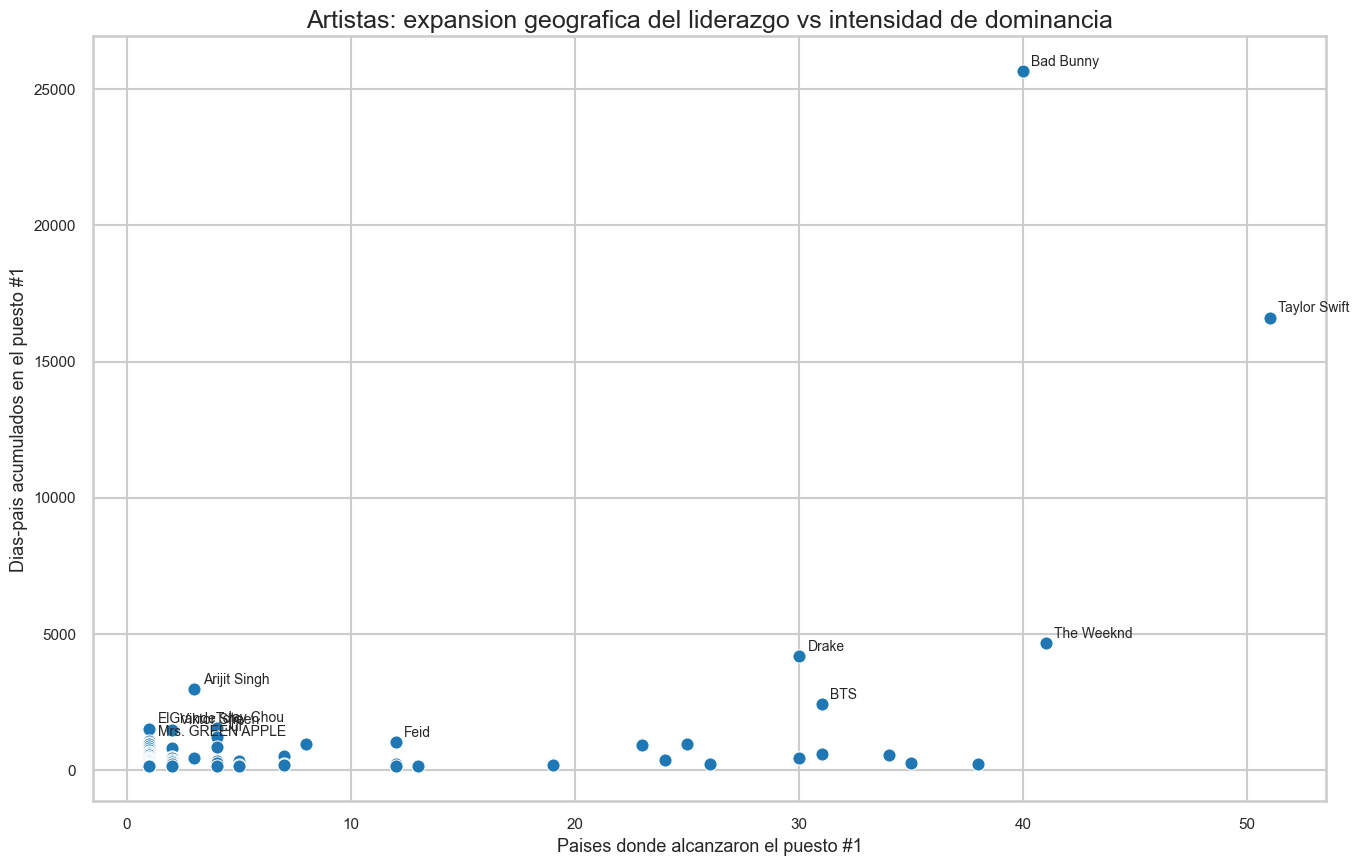

Lideres mas claramente locales:


,artist_name,dias_pais_en_no1,paises_con_no1
4,Arijit Singh,2972,3
7,ElGrandeToto,1519,1
8,Viktor Sheen,1498,2
10,Mrs. GREEN APPLE,1067,1
12,Hafdís Huld,988,1


Lideres mas claramente globales:


,artist_name,dias_pais_en_no1,paises_con_no1
0,Bad Bunny,25666,40
1,Taylor Swift,16612,51
2,The Weeknd,4662,41
3,Drake,4181,30
5,BTS,2431,31


In [15]:
if not top_no1.empty:
    pdf_alcance = top_no1[top_no1['dias_pais_en_no1'] >= 150].copy()
    destacar = pdf_alcance.sort_values(['dias_pais_en_no1', 'paises_con_no1'], ascending=[False, False]).head(12)

    plt.figure(figsize=(14, 9))
    sns.scatterplot(
        data=pdf_alcance,
        x='paises_con_no1',
        y='dias_pais_en_no1',
        s=90,
        color='#1f78b4'
    )
    for _, fila in destacar.iterrows():
        plt.annotate(fila['artist_name'], (fila['paises_con_no1'], fila['dias_pais_en_no1']), xytext=(6, 4), textcoords='offset points', fontsize=10)

    plt.title('Artistas: expansion geografica del liderazgo vs intensidad de dominancia')
    plt.xlabel('Paises donde alcanzaron el puesto #1')
    plt.ylabel('Dias-pais acumulados en el puesto #1')
    plt.tight_layout()
    plt.show()

    locales = pdf_alcance[pdf_alcance['paises_con_no1'] <= 3].sort_values('dias_pais_en_no1', ascending=False).head(5)
    globales = pdf_alcance[pdf_alcance['paises_con_no1'] >= 20].sort_values('dias_pais_en_no1', ascending=False).head(5)
    print('Lideres mas claramente locales:')
    display(locales)
    print('Lideres mas claramente globales:')
    display(globales)


### Insight 3: estabilidad y recambio del Top 50 de artistas

In [16]:
#Se define la fecha de corte para no considerar los datos del primer día y sesgar las nuevas entradas.

fecha_corte = "2021-10-21"

artistas_top50_diario = (
    chart_artistas
    .where((F.col('rank') <= 50) & (F.col('fecha') > fecha_corte))
    .groupBy('fecha') # Agrupamos por día
    .agg(
        # Sumamos todos los casos y dividimos entre el total de filas de ese día
        (F.sum(F.when(F.col('entry_status') == 'NEW_ENTRY', 1).otherwise(0)) / F.count('*')).alias('share_new_entry'),
        (F.sum(F.when(F.col('entry_status') == 'RE_ENTRY', 1).otherwise(0)) / F.count('*')).alias('share_re_entry'),
        (F.sum(F.when(F.col('entry_status') == 'NO_CHANGE', 1).otherwise(0)) / F.count('*')).alias('share_no_change'),
        (F.sum(F.when(F.col('entry_status').isin('MOVED_UP', 'MOVED_DOWN'), 1).otherwise(0)) / F.count('*')).alias('share_movement')
    )
    .orderBy('fecha')
    .toPandas()
)

# Convertimos los shares a porcentajes (opcional, para lectura humana)
cols_share = [c for c in artistas_top50_diario.columns if 'share' in c]
artistas_top50_diario[cols_share] = artistas_top50_diario[cols_share] * 100

artistas_top50_diario.head()

,fecha,share_new_entry,share_re_entry,share_no_change,share_movement
0,2021-10-22,0.838826,0.000000,21.360096,77.801078
1,2021-10-23,0.060024,0.000000,26.350540,73.589436
2,2021-10-24,0.030120,0.000000,30.512048,69.457831
3,2021-10-25,0.000000,0.300481,25.000000,74.699519
4,2021-10-26,0.030030,0.090090,40.450450,59.429429


En promedio, el 1.55% del Top 50 corresponde a ingresos/reingresos.
En promedio, el 29.85% del Top 50 permanece sin cambios.
Pico de recambio: 2022-02-20 con 4.33%


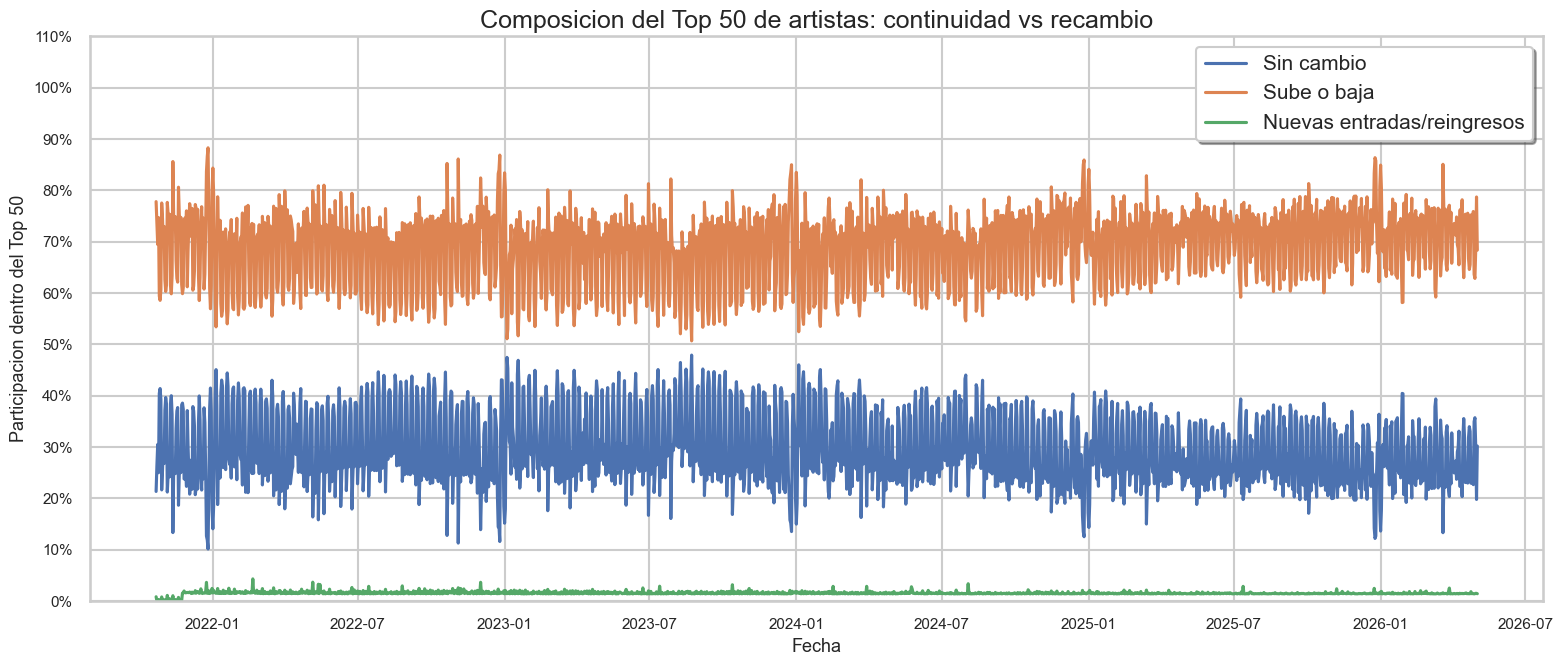

In [17]:
if not artistas_top50_diario.empty:
    if artistas_top50_diario['share_no_change'].max() > 1.0:
        cols = ['share_new_entry', 'share_re_entry', 'share_no_change', 'share_movement']
        artistas_top50_diario[cols] = artistas_top50_diario[cols] / 100

    # Métricas
    artistas_top50_diario['share_ingresos'] = artistas_top50_diario['share_new_entry'] + artistas_top50_diario['share_re_entry']
    promedio_ingresos = artistas_top50_diario['share_ingresos'].mean()
    promedio_no_change = artistas_top50_diario['share_no_change'].mean()
    pico = artistas_top50_diario.loc[artistas_top50_diario['share_ingresos'].idxmax()]

    print(f"En promedio, el {promedio_ingresos:.2%} del Top 50 corresponde a ingresos/reingresos.")
    print(f"En promedio, el {promedio_no_change:.2%} del Top 50 permanece sin cambios.")
    print(f"Pico de recambio: {pico['fecha']} con {pico['share_ingresos']:.2%}")

    plt.figure(figsize=(16, 7))
    plt.plot(artistas_top50_diario['fecha'], artistas_top50_diario['share_no_change'], label='Sin cambio')
    plt.plot(artistas_top50_diario['fecha'], artistas_top50_diario['share_movement'], label='Sube o baja')
    plt.plot(artistas_top50_diario['fecha'], artistas_top50_diario['share_ingresos'], label='Nuevas entradas/reingresos')

    # 1. Forzar el eje Y de 0 a 1.1 (110%) para dar aire arriba para la leyenda
    plt.ylim(0, 1.1)

    # 2. Formateador de porcentaje (1.0 = 100%)
    plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

    # 3. Definir marcas cada 10% para mayor claridad técnica
    plt.yticks([i/10 for i in range(12)])

    # 4. Ubicar la leyenda específicamente arriba a la derecha
    plt.legend(loc='upper right', fontsize='small', frameon=True, shadow=True)

    plt.title('Composicion del Top 50 de artistas: continuidad vs recambio')
    plt.xlabel('Fecha')
    plt.ylabel('Participacion dentro del Top 50')
    plt.tight_layout()
    plt.show()


### Insight 4: permanencia en chart segun banda de posicion

In [18]:
permanencia_por_banda = (
    chart_artistas.where(F.col('rank').isNotNull() & F.col('days_on_chart').isNotNull())
    .withColumn('banda_rank', banda_rank('rank'))
    .groupBy('banda_rank')
    .agg(
        F.percentile_approx('days_on_chart', 0.5, 1000).alias('mediana_dias_en_chart'),
        F.percentile_approx('consecutive_days', 0.5, 1000).alias('mediana_dias_consecutivos'),
        F.avg(F.when(F.col('entry_status') == 'NEW_ENTRY', 1).otherwise(0)).alias('share_new_entry')
    )
    .toPandas()
)

if not permanencia_por_banda.empty:
    permanencia_por_banda['orden'] = permanencia_por_banda['banda_rank'].map({b: i for i, b in enumerate(ORDEN_BANDAS)})
    permanencia_por_banda = permanencia_por_banda.sort_values('orden')
    permanencia_por_banda

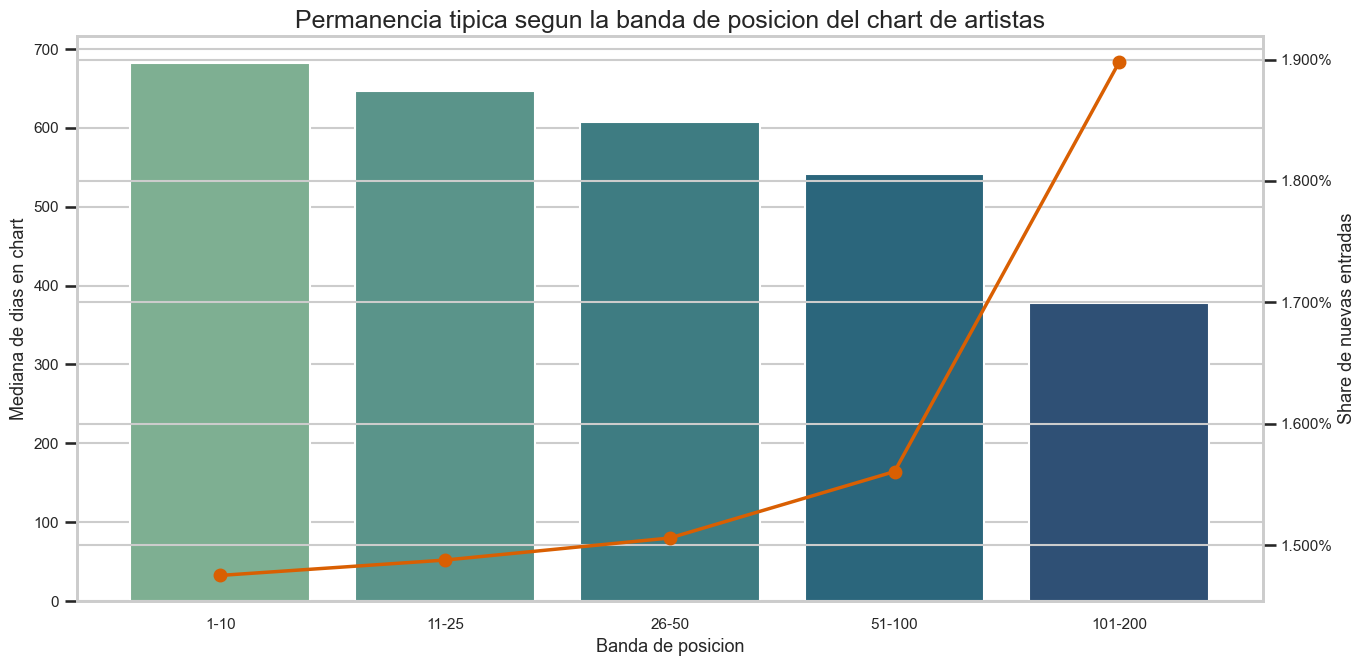

La mediana de permanencia en la banda 1-10 es de 682 dias, frente a 378 dias en la banda 101-200.


In [19]:
if not permanencia_por_banda.empty:
    fig, ax1 = plt.subplots(figsize=(14, 7))
    sns.barplot(data=permanencia_por_banda, x='banda_rank', y='mediana_dias_en_chart', palette='crest', ax=ax1)
    ax1.set_title('Permanencia tipica segun la banda de posicion del chart de artistas')
    ax1.set_xlabel('Banda de posicion')
    ax1.set_ylabel('Mediana de dias en chart')

    ax2 = ax1.twinx()
    ax2.plot(permanencia_por_banda['banda_rank'], permanencia_por_banda['share_new_entry'], color='#d95f02', marker='o', linewidth=2.5)
    ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax2.set_ylabel('Share de nuevas entradas')

    plt.tight_layout()
    plt.show()

    top10 = permanencia_por_banda.loc[permanencia_por_banda['banda_rank'] == '1-10', 'mediana_dias_en_chart'].iloc[0]
    bottom = permanencia_por_banda.loc[permanencia_por_banda['banda_rank'] == '101-200', 'mediana_dias_en_chart'].iloc[0]
    print(f"La mediana de permanencia en la banda 1-10 es de {int(top10)} dias, frente a {int(bottom)} dias en la banda 101-200.")


### Insight 5: diversidad de lideres diarios en el puesto #1

In [20]:
diversidad_no1 = (
    chart_artistas.where(F.col('rank') == 1)
    .groupBy('fecha')
    .agg(F.countDistinct('artist_name').alias('artistas_distintos_en_no1'))
    .orderBy('fecha')
    .toPandas()
)

if not diversidad_no1.empty:
    diversidad_no1['promedio_30d'] = diversidad_no1['artistas_distintos_en_no1'].rolling(30, min_periods=1).mean()
    diversidad_no1.head()


En un dia tipico, el puesto #1 es ocupado por 36.3 artistas distintos al sumar todos los paises.
El minimo observado fue 15 y el maximo 50 artistas distintos liderando simultaneamente.


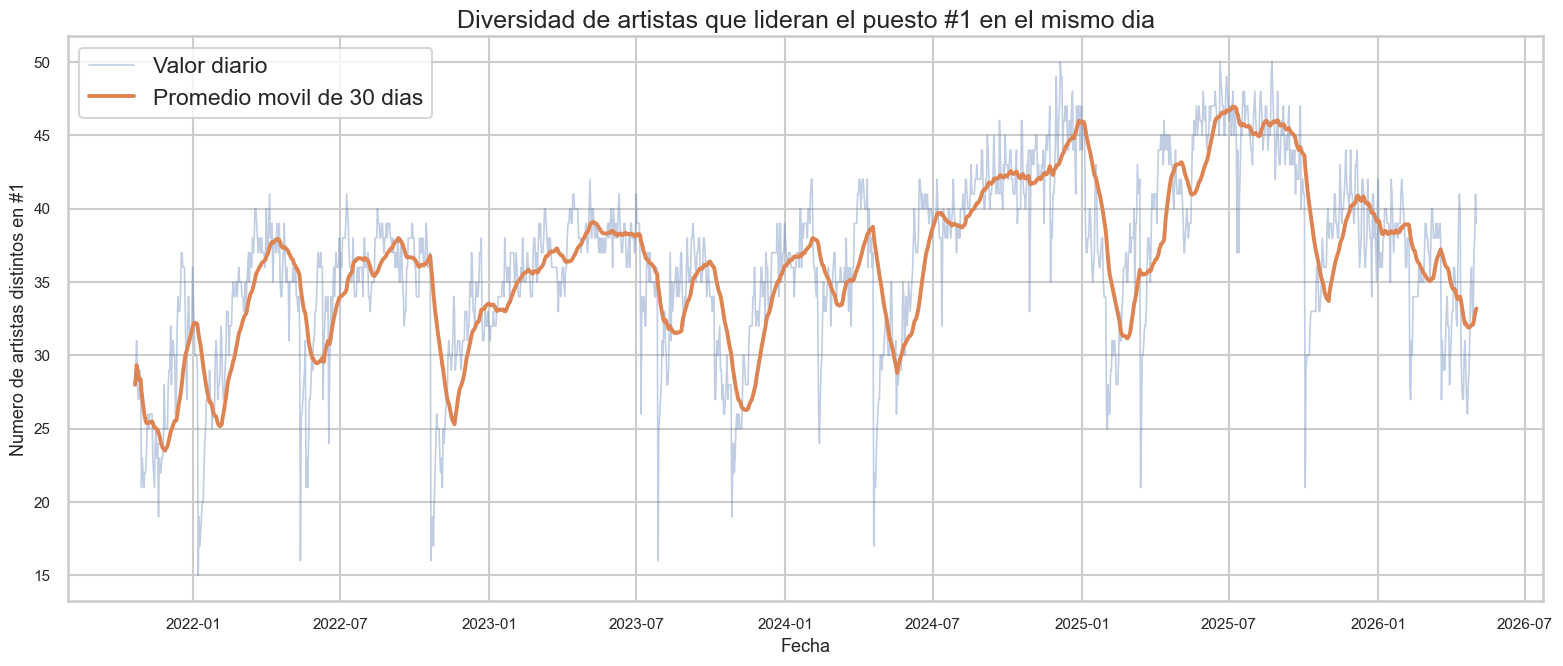

In [21]:
if not diversidad_no1.empty:
    minimo = diversidad_no1['artistas_distintos_en_no1'].min()
    maximo = diversidad_no1['artistas_distintos_en_no1'].max()
    promedio = diversidad_no1['artistas_distintos_en_no1'].mean()
    print(f"En un dia tipico, el puesto #1 es ocupado por {promedio:.1f} artistas distintos al sumar todos los paises.")
    print(f"El minimo observado fue {int(minimo)} y el maximo {int(maximo)} artistas distintos liderando simultaneamente.")

    plt.figure(figsize=(16, 7))
    plt.plot(diversidad_no1['fecha'], diversidad_no1['artistas_distintos_en_no1'], alpha=0.35, linewidth=1.2, label='Valor diario')
    plt.plot(diversidad_no1['fecha'], diversidad_no1['promedio_30d'], linewidth=2.8, label='Promedio movil de 30 dias')
    plt.title('Diversidad de artistas que lideran el puesto #1 en el mismo dia')
    plt.xlabel('Fecha')
    plt.ylabel('Numero de artistas distintos en #1')
    plt.legend()
    plt.tight_layout()
    plt.show()

### Insight 6: mercados mas estables y mas volatiles en el Top 10 de artistas

In [22]:
from pyspark.sql import functions as F

# Agregación para todos los diagnósticos
diagnostico_base = (
    chart_artistas.where(F.col('rank') <= 10)
    .groupBy('pais')
    .agg(
        F.count('*').alias('observaciones_top10'),
        F.countDistinct('fecha').alias('dias_cubiertos'),
        (F.sum(F.when(F.col('entry_status') == 'NEW_ENTRY', 1).otherwise(0)) / F.count('*')).alias('share_new_entry_top10'),
        (F.sum(F.when(F.col('entry_status') == 'NO_CHANGE', 1).otherwise(0)) / F.count('*')).alias('share_no_change_top10'),
        F.percentile_approx('days_on_chart', 0.5, 1000).alias('mediana_days_on_chart')
    )
    .where(F.col('observaciones_top10') >= 1000)
    .cache() # Cacheamos este resultado para los filtros siguientes
)

condicion_anomala = (
    (F.col('share_new_entry_top10') >= 0.90) |
    ((F.col('share_no_change_top10') == 0) & (F.col('mediana_days_on_chart') <= 1))
)

mercados_anomalos = (
    diagnostico_base
    .where(condicion_anomala)
    .orderBy('pais')
    .toPandas()
)

volatilidad_por_pais = (
    diagnostico_base
    .where(~condicion_anomala) # NOT (~) para obtener los mercados sanos
    .orderBy(F.desc('share_new_entry_top10'))
    .toPandas()
)

diagnostico_base.unpersist()

if not mercados_anomalos.empty:
    print('Mercados excluidos por patrón anómalo:')
    display(mercados_anomalos)

print('\nTop 15 Mercados por Volatilidad (Sanos):')
display(volatilidad_por_pais.head(15))

Mercados excluidos por patrón anómalo:


,pais,observaciones_top10,dias_cubiertos,share_new_entry_top10,share_no_change_top10,mediana_days_on_chart
0,ve,16210,1621,1.0,0.0,1



Top 15 Mercados por Volatilidad (Sanos):


,pais,observaciones_top10,dias_cubiertos,share_new_entry_top10,share_no_change_top10,mediana_days_on_chart
0,lu,16550,1655,0.004773,0.421994,614
1,th,16550,1655,0.001692,0.565196,626
2,is,16550,1655,0.001631,0.503142,691
3,vn,16550,1655,0.001511,0.576375,574
4,ee,16550,1655,0.001450,0.515468,688
5,sa,16550,1655,0.001208,0.607311,726
6,kr,16550,1655,0.001088,0.634985,558
7,cz,16550,1655,0.001088,0.624230,799
8,ae,16550,1655,0.001027,0.652810,746
9,ch,16550,1655,0.001027,0.474320,775


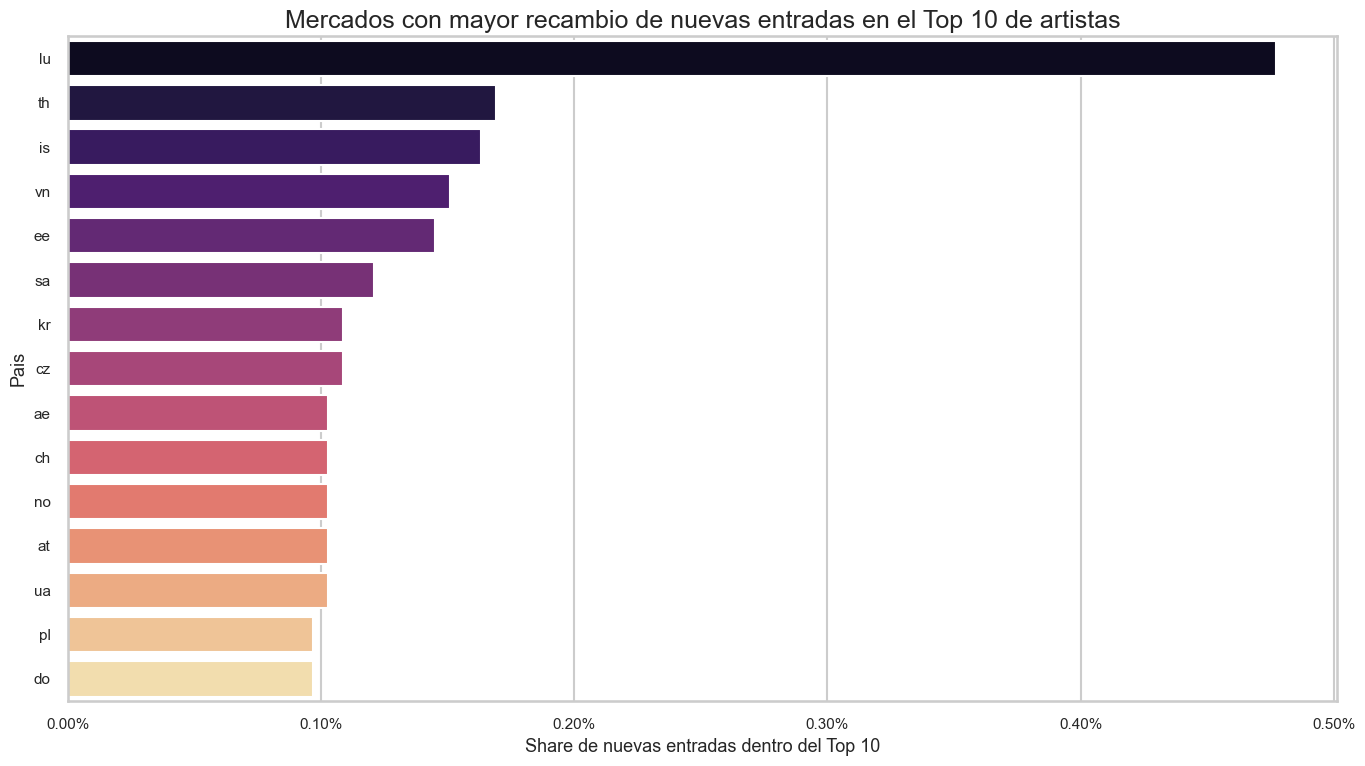

Nota metodologica: se excluyeron mercados con patron claramente anomalo, por ejemplo aquellos donde casi el 100% del Top 10 aparece como NEW_ENTRY todos los dias.
Mercados mas estables segun el share de posiciones sin cambio en el Top 10:


,pais,share_no_change_top10,share_new_entry_top10,observaciones_top10,dias_cubiertos,mediana_days_on_chart
64,in,0.853172,0.000604,16550,1655,797
58,eg,0.757281,0.000665,16550,1655,708
63,jp,0.737160,0.000604,16550,1655,738
45,pk,0.735059,0.000759,14490,1449,700
39,sv,0.732024,0.000785,16550,1655,682
48,co,0.722356,0.000725,16550,1655,752
62,cl,0.717039,0.000604,16550,1655,635
67,es,0.715166,0.000604,16550,1655,705
40,ph,0.712266,0.000785,16550,1655,626
59,pe,0.707976,0.000665,16550,1655,775


Mercados mas volatiles despues de limpiar anomalias:


,pais,share_new_entry_top10,share_no_change_top10,observaciones_top10,dias_cubiertos,mediana_days_on_chart
0,lu,0.004773,0.421994,16550,1655,614
1,th,0.001692,0.565196,16550,1655,626
2,is,0.001631,0.503142,16550,1655,691
3,vn,0.001511,0.576375,16550,1655,574
4,ee,0.001450,0.515468,16550,1655,688
5,sa,0.001208,0.607311,16550,1655,726
6,kr,0.001088,0.634985,16550,1655,558
7,cz,0.001088,0.624230,16550,1655,799
8,ae,0.001027,0.652810,16550,1655,746
9,ch,0.001027,0.474320,16550,1655,775


In [23]:
if not volatilidad_por_pais.empty:
    top_volatiles = volatilidad_por_pais.head(15).copy()
    plt.figure(figsize=(14, 8))
    sns.barplot(data=top_volatiles, x='share_new_entry_top10', y='pais', palette='magma')
    plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))
    plt.title('Mercados con mayor recambio de nuevas entradas en el Top 10 de artistas')
    plt.xlabel('Share de nuevas entradas dentro del Top 10')
    plt.ylabel('Pais')
    plt.tight_layout()
    plt.show()

    print('Nota metodologica: se excluyeron mercados con patron claramente anomalo, por ejemplo aquellos donde casi el 100% del Top 10 aparece como NEW_ENTRY todos los dias.')

    top_estables = volatilidad_por_pais.sort_values('share_no_change_top10', ascending=False).head(10)
    print('Mercados mas estables segun el share de posiciones sin cambio en el Top 10:')
    display(top_estables[['pais', 'share_no_change_top10', 'share_new_entry_top10', 'observaciones_top10', 'dias_cubiertos', 'mediana_days_on_chart']])

    print('Mercados mas volatiles despues de limpiar anomalias:')
    display(top_volatiles[['pais', 'share_new_entry_top10', 'share_no_change_top10', 'observaciones_top10', 'dias_cubiertos', 'mediana_days_on_chart']])


## **Estadistica de los Datos**

In [24]:
# Filtro del mercado anomalo (Venezuela)
chart_artistas_clean = chart_artistas.where(F.col('pais') != 've').cache()

print(f"Registros después de limpieza: {chart_artistas_clean.count():,}")

[Stage 73:================================================>       (18 + 3) / 21]

Registros después de limpieza: 22,387,149


In [25]:
# Estadísticas descriptivas usando el DF limpio

#Estadisticas de Permanencia en el Chart

stats_permanencia = chart_artistas_clean.agg(
    F.min("days_on_chart").alias("min"),
    F.avg("days_on_chart").alias("media"),
    F.percentile_approx("days_on_chart", 0.5).alias("mediana"),
    F.stddev("days_on_chart").alias("DE"),
    F.percentile_approx("days_on_chart", 0.9).alias("p90"),
    F.max("days_on_chart").alias("max"),
    (F.count(F.when(F.col("days_on_chart") > 365, 1)) / F.count("*") * 100).alias("pct_supera_365")
)
stats_permanencia.show()

[Stage 79:>                                                         (0 + 1) / 1]

+---+-----------------+-------+------------------+----+----+-----------------+
|min|            media|mediana|                DE| p90| max|   pct_supera_365|
+---+-----------------+-------+------------------+----+----+-----------------+
|  1|589.2420042409152|    492|458.02973858189176|1299|1655|59.19269130696365|
+---+-----------------+-------+------------------+----+----+-----------------+



In [26]:
#Estadisticas de Globalidad

presencia_paises = chart_artistas_clean.groupBy("artist_name").agg(F.countDistinct("pais").alias("num_paises"))

stats_globalidad = presencia_paises.agg(
    F.avg("num_paises").alias("media"),
    F.percentile_approx("num_paises", 0.5).alias("mediana"),
    F.stddev("num_paises").alias("DE"),
    F.percentile_approx("num_paises", 0.9).alias("p90"),
    F.percentile_approx("num_paises", 0.95).alias("p95"),
    F.max("num_paises").alias("max"),
    (F.count(F.when(F.col("num_paises") > 10, 1)) / F.count("*") * 100).alias("pct_mas_10_paises")
)
stats_globalidad.show()

[Stage 80:=====================================================>  (20 + 1) / 21]

+------------------+-------+----------------+---+---+---+-----------------+
|             media|mediana|              DE|p90|p95|max|pct_mas_10_paises|
+------------------+-------+----------------+---+---+---+-----------------+
|2.7934921403725066|      1|7.00304858487314|  4|  9| 70| 4.55726300030822|
+------------------+-------+----------------+---+---+---+-----------------+



In [27]:
#Estadisticas de Ranking

stats_ranking = chart_artistas_clean.agg(
    F.min("rank").alias("min"),
    F.avg("rank").alias("media"),
    F.percentile_approx("rank", 0.5).alias("mediana"),
    F.stddev("rank").alias("DE"),
    F.max("rank").alias("max"),
    (F.count(F.when(F.col("rank") <= 50, 1)) / F.count("*") * 100).alias("pct_1_50"),
    (F.count(F.when(F.col("rank") > 50, 1)) / F.count("*") * 100).alias("pct_51_200")
)
stats_ranking.show()

[Stage 90:=============================================>          (17 + 4) / 21]

+---+----------------+-------+-----------------+---+------------------+-----------------+
|min|           media|mediana|               DE|max|          pct_1_50|       pct_51_200|
+---+----------------+-------+-----------------+---+------------------+-----------------+
|  1|99.0310276668101|     98|57.62382493044115|200|25.738976410082408|74.26102358991758|
+---+----------------+-------+-----------------+---+------------------+-----------------+



## **Parametros para realizar la Partición**

Los parametros de partición que se definieron son los siguientes:

* **Alcance Local o Global:**  Para este parametro se tomaran las columnas *artist_name*, *country* y *date* y se realizará un conteo diario de los paises en los que esta presente el artista.  Si el artista esta presente en mas de 10 paises, se catalogara como Global.
* **Artista Nuevo o Veterano:**  Para este parametro se tomaran las columnas *artist_name*, *days_on_chart* y *date*.  Si el artista tiene mas de 365 días en el chart, se define como veterano.
* **Desempeño (Top o Estable):** Para este parametro se tomaran las columnas *artist_name*, *country*, *rank* y *date*.  Si el artista esta entre los primeros 50 lugares en el país, es considerado Top, de lo contrario Estable.

In [28]:
chart_artistas_clean.groupBy('artist_name').count().orderBy('count', ascending=False).show(10)

[Stage 93:==================================================>     (19 + 2) / 21]

+---------------+------+
|    artist_name| count|
+---------------+------+
|     The Weeknd|115396|
|   Taylor Swift|115073|
|  Billie Eilish|113445|
|  Ariana Grande|113091|
|  Justin Bieber|110856|
|       Dua Lipa|108042|
|          Drake|108011|
|   Lana Del Rey|106835|
|       Coldplay|106560|
|Imagine Dragons|104212|
+---------------+------+
only showing top 10 rows


In [29]:

chart_artistas_clean.agg(F.min('fecha').alias('min_date'), F.max('fecha').alias('max_date')).show()

+----------+----------+
|  min_date|  max_date|
+----------+----------+
|2021-10-21|2026-05-02|
+----------+----------+



In [30]:
chart_artistas_clean.groupBy('entry_status').count().orderBy('count', ascending=False).show()

[Stage 99:========================>                                (9 + 8) / 21]

+------------+-------+
|entry_status|  count|
+------------+-------+
|  MOVED_DOWN|9846642|
|    MOVED_UP|8920824|
|   NO_CHANGE|2857599|
|    RE_ENTRY| 698185|
|   NEW_ENTRY|  63899|
+------------+-------+



**Definición de Local o Global**

In [31]:
# Contar la presencia de países por artista y día

df_counts = chart_artistas_clean.groupBy("fecha", "artist_name").agg(
    F.count("pais").alias("total_countries"),
    F.max(F.when(F.col("pais") == "global", 1).otherwise(0)).alias("in_global_chart")
)

# Unir esta información con el DataFrame original (D)
df_with_scope = chart_artistas_clean.join(df_counts, ["fecha", "artist_name"], "left")

In [32]:
# Crear la columna de caracterización 'Scope'
df_final = df_with_scope.withColumn(
    "Scope",
    F.when(
        (F.col("in_global_chart") == 1) | (F.col("total_countries") > 10),
        "Global"
    ).otherwise("Local")
)

# 4. Verificar el resultado con una muestra
df_final.select("fecha", "artist_name", "pais", "total_countries", "Scope").show(10)

[Stage 106:>                                                        (0 + 1) / 1]

+----------+-----------------+----+---------------+------+
|     fecha|      artist_name|pais|total_countries| Scope|
+----------+-----------------+----+---------------+------+
|2021-10-21|         Dua Lipa|  ae|             67|Global|
|2021-10-21|         RAP VIỆT|  vn|              1| Local|
|2021-10-21|    Sơn Tùng M-TP|  vn|              1| Local|
|2022-04-09|     El Jordan 23|  cl|              1| Local|
|2022-04-09|   Rauw Alejandro|  cl|             22|Global|
|2022-07-19|     Jacky Cheung|  hk|              4| Local|
|2022-11-20|    Mohit Chauhan|  pk|              3| Local|
|2022-11-20|      Tulsi Kumar|  pk|              2| Local|
|2022-12-12|      Only Monday|  th|              1| Local|
|2023-01-25|Fabrizio De André|  it|              1| Local|
+----------+-----------------+----+---------------+------+
only showing top 10 rows


**Definir Top o LongTail (Estable)**


In [33]:
# Agregación para Alcance (Scope)
# Calculamos la presencia global por día antes de unir
df_counts = chart_artistas_clean.groupBy("fecha", "artist_name").agg(
    F.count("pais").alias("total_countries"),
    F.max(F.when(F.col("pais") == "global", 1).otherwise(0)).alias("in_global_chart")
)

df_caracterizado = chart_artistas_clean.join(df_counts, ["fecha", "artist_name"], "left") \
    .withColumn(
        # Regla A: Alcance (Global vs Local)
        "Scope",
        F.when((F.col("in_global_chart") == 1) | (F.col("total_countries") > 10), "Global").otherwise("Local")
    ) \
    .withColumn(
        # Regla B: Desempeño (Top vs LongTail)
        "Tier",
        F.when(F.col("rank") <= 50, "Top").otherwise("LongTail")
    ) \
    .withColumn(
        # Regla C: Madurez (Veteran vs New)
        "Seniority",
        F.when(F.col("days_on_chart") > 365, "Veteran").otherwise("New")
    )

# Limpieza de columnas auxiliares para optimizar memoria
df_final = df_caracterizado.drop("total_countries", "in_global_chart")

# Verificación de los 8 grupos potenciales
df_final.select("artist_name", "pais", "Scope", "Tier", "Seniority").show(10)

[Stage 111:>                                                        (0 + 1) / 1]

+-----------------+----+------+--------+---------+
|      artist_name|pais| Scope|    Tier|Seniority|
+-----------------+----+------+--------+---------+
|         Dua Lipa|  ae|Global|     Top|      New|
|         RAP VIỆT|  vn| Local|     Top|      New|
|    Sơn Tùng M-TP|  vn| Local|     Top|      New|
|     El Jordan 23|  cl| Local|     Top|      New|
|   Rauw Alejandro|  cl|Global|     Top|      New|
|     Jacky Cheung|  hk| Local|     Top|      New|
|    Mohit Chauhan|  pk| Local|     Top|      New|
|      Tulsi Kumar|  pk| Local|     Top|      New|
|      Only Monday|  th| Local|LongTail|      New|
|Fabrizio De André|  it| Local|LongTail|  Veteran|
+-----------------+----+------+--------+---------+
only showing top 10 rows


## **Calculo de Probabilidades**

Se filtra la base que sea mayor a 2022-10-21 ya que la variable de veterania va a obtener todos valores de New antes de 1 año, solamente por la falta de información historica.

Despues calculamos el valor de cada uno de los grupos.

In [34]:
# Aplicar el filtro temporal para evitar sesgo de veteranía
df_filtrado = df_final.filter(F.col("fecha") >= "2022-10-21")


datos_filtrados = df_filtrado.select(
    F.lit("Artistas diarios").alias("dataset"),
    F.count("*").alias("filas"),
    F.countDistinct("pais").alias("paises"),
    F.countDistinct("artist_name").alias("artistas_distintos"),
    F.countDistinct("artist_uri").alias("artistas_distintos_uri"),
    F.min("fecha").alias("fecha_min"),
    F.max("fecha").alias("fecha_max")
)

resumen_filtrado = datos_filtrados.toPandas()

display(resumen_filtrado)


,dataset,filas,paises,artistas_distintos,artistas_distintos_uri,fecha_min,fecha_max
0,Artistas diarios,17656239,70,20648,20921,2022-10-21,2026-05-02


In [35]:
# Calcular el total de registros en la población D filtrada
total_registros = df_filtrado.count()

# Obtener los conteos y porcentajes por cada una de las 8 combinaciones
proporciones_grupos = df_filtrado.groupBy("Seniority", "Scope", "Tier") \
    .count() \
    .withColumn("Probabilidad_Ocurrencia", F.round((F.col("count") / total_registros)*100, 2)) \
    .orderBy(F.desc("Probabilidad_Ocurrencia"))

# Mostrar la tabla de probabilidades
proporciones_grupos.show()

[Stage 125:=============================================>          (9 + 2) / 11]

+---------+------+--------+-------+-----------------------+
|Seniority| Scope|    Tier|  count|Probabilidad_Ocurrencia|
+---------+------+--------+-------+-----------------------+
|  Veteran|Global|LongTail|4696598|                   26.6|
|  Veteran| Local|LongTail|4546998|                  25.75|
|      New| Local|LongTail|2442913|                  13.84|
|  Veteran|Global|     Top|2378095|                  13.47|
|  Veteran| Local|     Top|1629865|                   9.23|
|      New|Global|LongTail|1456544|                   8.25|
|      New| Local|     Top| 253659|                   1.44|
|      New|Global|     Top| 251567|                   1.42|
+---------+------+--------+-------+-----------------------+



## **Validación de Particiones**

In [39]:
# Función para verificar el funcionamiento
#Verifica el numero de registros de cada bloque.  Deben ser iguales al count obtenido anteriormente.

def verificar_particion(df, nombre, scope, tier, seniority):
    submuestra = df.filter((F.col("Scope") == scope) &
                           (F.col("Tier") == tier) &
                           (F.col("Seniority") == seniority))
    print(f"Verificación {nombre}: {submuestra.count()} registros encontrados.")
    return submuestra

# Bloques de Extracción

# G1: Global + Top + Veteran (Top Consolidada)
g1_sub = verificar_particion(df_filtrado, "G1", "Global", "Top", "Veteran")

# G2: Global + Top + New (Hits Virales)
g2_sub = verificar_particion(df_filtrado, "G2", "Global", "Top", "New")

# G3: Global + LongTail + Veteran (Catálogo Internacional)
g3_sub = verificar_particion(df_filtrado, "G3", "Global", "LongTail", "Veteran")

# G4: Global + LongTail + New (New Internacionales)
g4_sub = verificar_particion(df_filtrado, "G4", "Global", "LongTail", "New")

# G5: Local + Top + Veteran (Locales Reconocidos)
g5_sub = verificar_particion(df_filtrado, "G5", "Local", "Top", "Veteran")

# G6: Local + Top + New (Éxitos Locales Recientes)
g6_sub = verificar_particion(df_filtrado, "G6", "Local", "Top", "New")

# G7: Local + LongTail + Veteran (Nicho Local Consolidado)
g7_sub = verificar_particion(df_filtrado, "G7", "Local", "LongTail", "Veteran")

# G8: Local + LongTail + New (Masiva Local Transitoria)
g8_sub = verificar_particion(df_filtrado, "G8", "Local", "LongTail", "New")

Verificación G1: 2378095 registros encontrados.


Verificación G2: 251567 registros encontrados.


Verificación G3: 4696598 registros encontrados.


Verificación G4: 1456544 registros encontrados.


Verificación G5: 1629865 registros encontrados.


Verificación G6: 253659 registros encontrados.


Verificación G7: 4546998 registros encontrados.


[Stage 274:>                                                        (0 + 8) / 9]

Verificación G8: 2442913 registros encontrados.


In [51]:
#Se imprime una muestra de cada grupo, validando los valores de los parametros

grupos = [g1_sub, g2_sub, g3_sub, g4_sub, g5_sub, g6_sub, g7_sub, g8_sub]

for idx, i in enumerate(grupos, start=1):
    info = i.select("Scope", "Tier", "Seniority").first()
    
    detalles = f"{info['Scope']} | {info['Tier']} | {info['Seniority']}"
    
    print("=" * 70)
    print(f"Muestra de registros del Grupo G{idx}: {detalles}")
    print("-" * 70)
    
    i.select("fecha", "artist_name", "pais", "rank", "days_on_chart").show(5)
    print("\n")

Muestra de registros del Grupo G1: Global | Top | Veteran
----------------------------------------------------------------------


+----------+-----------+----+----+-------------+
|     fecha|artist_name|pais|rank|days_on_chart|
+----------+-----------+----+----+-------------+
|2022-10-21|A.R. Rahman|  ae|   9|          366|
|2022-10-21|A.R. Rahman|  in|   3|          366|
|2022-10-21|A.R. Rahman|  my|  25|          366|
|2022-10-21|A.R. Rahman|  sg|  42|          366|
|2022-10-21| AP Dhillon|  in|   9|          366|
+----------+-----------+----+----+-------------+
only showing top 5 rows




Muestra de registros del Grupo G2: Global | Top | New
----------------------------------------------------------------------


+----------+-----------+----+----+-------------+
|     fecha|artist_name|pais|rank|days_on_chart|
+----------+-----------+----+----+-------------+
|2022-10-21|A.R. Rahman|  pk|  28|          160|
|2022-10-21| AP Dhillon|  ae|  29|          336|
|2022-10-21| AP Dhillon|  pk|   2|          160|
|2022-10-21| Bebe Rexha|  at|  42|           73|
|2022-10-21| Bebe Rexha|  be|  36|           57|
+----------+-----------+----+----+-------------+
only showing top 5 rows




Muestra de registros del Grupo G3: Global | LongTail | Veteran
----------------------------------------------------------------------


...

Muestra de registros del Grupo G7: Local | LongTail | Veteran
----------------------------------------------------------------------


+----------+-----------+----+----+-------------+
|     fecha|artist_name|pais|rank|days_on_chart|
+----------+-----------+----+----+-------------+
|2022-10-21|     $hirak|  nl| 166|          366|
|2022-10-21|      1.Cuz|  se|  56|          366|
|2022-10-21|      10AGE|  ua| 160|          366|
|2022-10-21|  1PLIKÉ140|  fr|  86|          366|
|2022-10-21|     7-Toun|  ma|  72|          366|
+----------+-----------+----+----+-------------+
only showing top 5 rows




Muestra de registros del Grupo G8: Local | LongTail | New
----------------------------------------------------------------------


[Stage 605:>                                                        (0 + 1) / 1]

+----------+--------------------+----+----+-------------+
|     fecha|         artist_name|pais|rank|days_on_chart|
+----------+--------------------+----+----+-------------+
|2022-10-21|"Tito ""El Bambin...|  bo| 196|           63|
|2022-10-21|"Tito ""El Bambin...|  cl| 180|          157|
|2022-10-21|"Tito ""El Bambin...|  ec| 154|          158|
|2022-10-21|"Tito ""El Bambin...|  gt| 150|          251|
|2022-10-21|"Tito ""El Bambin...|  hn| 155|          243|
+----------+--------------------+----+----+-------------+
only showing top 5 rows


